# Earnings-Call Tone — a quantitative teardown 🔬
### net-tone → post-call CAR · naive vs surprise-controlled slope · the false-positive at the null · label-shuffle placebo · tone long-short with costs & borrow · four-window sweep · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Confounded_by_the_number%3F: Named](https://img.shields.io/badge/Confounded_by_the_number%3F-Named-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We regress post-call CAR on net tone, control for the numeric surprise to isolate the **linguistic** edge, and show that skipping that control manufactures a false positive.

> ⚠️ **Not investment advice.** **Synthetic-only** study: no free feed of scored transcripts × event-time CAR exists, so the panel is deterministic (seed 566, planted `tone_beta=0.02`, 480 calls, panel fp `3ec051a6458a`) and the real fetch is an empty stub — the Signal axis is **capped at `WEAK`**. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from earnings_call_tone import data, strategy as st

TONE_BETA = 0.020
PANEL, TRUTH = data.synthetic_panel(tone_beta=TONE_BETA, seed=566)

# This study is SYNTHETIC-ONLY: no free real tape exists, so the real fetch is an empty stub.
REAL = data.fetch_panel(fetch=False)
HAVE_REAL = not REAL.empty
print("synthetic panel:", len(PANEL), "calls | fp", data.fingerprint(PANEL))
print("real tape present:", HAVE_REAL, "(synthetic-only study — real fetch is an empty stub by design)")


synthetic panel: 480 calls | fp 3ec051a6458a
real tape present: False (synthetic-only study — real fetch is an empty stub by design)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Surprise-controlled tone slope-*t* **+7.95** (placebo *p* 0.0005) on the planted panel, flat **-0.19** at the null — but **no real tape** exists, so `REAL` (robust *t* ≥ 2 on real data) is unreachable → capped `WEAK`. |
| **Tradability** | `FRAGILE` | Naive tone long-short gross **+23.0%/yr** → net **+21.7%/yr**, but it is PEAD-inflated; the *isolated* edge needs vendor-grade scoring to capture. |
| **Confounded by the number?** | `NAMED` | At the null the *naive* slope-*t* averages **+6.5** (false positive) vs controlled **-0.19**. |

> 💡 In plain words: the engine is faithful (the synthetic control proves it), but a `REAL` stamp needs a real tape we don't have, and the naive read is a confound — hence `WEAK` × `FRAGILE`, confound `NAMED`.

## 1 · The claim, steelmanned

Let $T_i$ be call $i$'s net tone, $S_i$ its numeric earnings surprise, and $C_i$ its post-call CAR.

- **H₁ (naive).** slope of $C$ on $T$ alone $> 0$ at *t* ≥ 2.
- **H₂ (the real claim).** slope of $C$ on $T$ **controlling for $S$** $> 0$ at *t* ≥ 2 — tone adds information *beyond the number*.
- **H₃ (robustness).** the controlled sign holds across sub-panels.
- **H₄ (net).** a tradable tone long-short survives costs + the guarded-leg borrow.

The honest test is **H₂**. H₁ is a trap: because $\text{corr}(T,S) > 0$, H₁ can be 'confirmed' even when tone is useless (H₂ false). We show exactly that below.

## 2 · So what? — what rides on each answer

The content is **partialling-out**. Upbeat calls follow beats, so $T$ and $S$ are collinear; the naive slope of $C$ on $T$ absorbs the PEAD coefficient on $S$. Only the *controlled* tone coefficient (Frisch-Waugh-Lovell) isolates the linguistic channel. This maps to the desk's numeric drifts — [363 PEAD](../../363-pead-drift/), [534 revenue-surprise](../../534-revenue-surprise-drift/) — which are the $S$ that $T$ must beat, and is distinct from the aggregate-mood studies ([259 news-tone](../../259-news-tone/), [392 glassdoor](../../392-glassdoor-sentiment/)).

## 3 · How we'd know — the protocol

- **Score.** Net tone $T$ = (positive − negative) sentiment-word share (Loughran-McDonald lexicon); numeric surprise $S$ = standardised SUE.
- **Outcome.** Post-call CAR $C$ (market-adjusted return *after* the call).
- **Naive slope.** OLS $C \sim T$ — the PEAD-inflated read (H₁).
- **Controlled slope.** OLS $C \sim [T, S]$ — the *tone* coefficient is the isolated edge (H₂).
- **Placebo.** Shuffle $T$ against $(C, S)$, refit the controlled slope, read the tail (2000 perms).
- **Long-short.** Long the upbeat tone tail, short the guarded tail; costs + borrow.
- **Robustness.** Controlled slope-*t* over four contiguous sub-panels.
- **Positive control.** Deterministic worlds with planted `tone_beta` (0 = null), averaged over 25 seeds (house rule).

Timing: tone is known at the call; CAR is measured strictly after; entry is the next session. One documented execution lag, applied identically in the sweep and the control.

## 4 · The teardown

### 4a · Naive vs surprise-controlled slope — H₁ vs H₂

The whole study in one cell: the tone slope before and after subtracting the number.

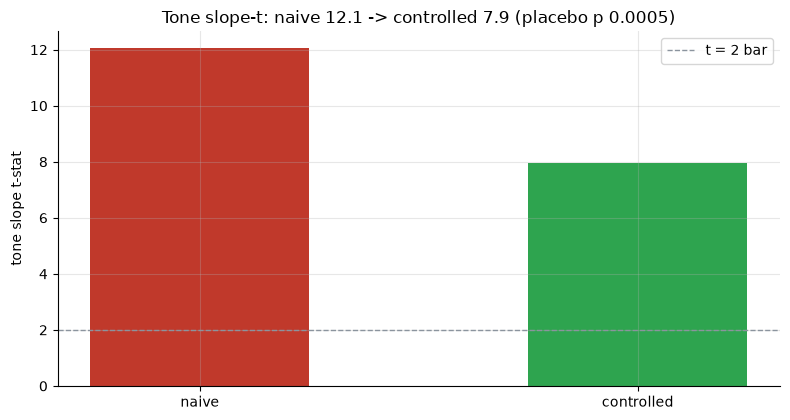

                                   tone_slope   tone_t
regression                                            
C ~ tone (naive)                       0.0251  12.0519
C ~ [tone, surprise] (controlled)      0.0176   7.9451
placebo p (controlled slope): 0.0005


In [2]:
naive = st.tone_regression(PANEL, control_surprise=False)
ctrl  = st.tone_regression(PANEL, control_surprise=True)
p = st.placebo_pvalue(PANEL, n_perm=2000, seed=566)
tab = pd.DataFrame({
    'regression': ['C ~ tone (naive)', 'C ~ [tone, surprise] (controlled)'],
    'tone_slope': [naive['tone_slope'], ctrl['tone_slope']],
    'tone_t': [naive['tone_t'], ctrl['tone_t']],
}).set_index('regression')
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(range(2), tab['tone_t'], color=[RED, GREEN], width=.5)
ax.set_xticks(range(2)); ax.set_xticklabels(['naive','controlled'])
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar'); ax.legend()
ax.set_ylabel('tone slope t-stat')
ax.set_title(f"Tone slope-t: naive {naive['tone_t']:.1f} -> controlled {ctrl['tone_t']:.1f} (placebo p {p:.4f})")
plt.tight_layout(); plt.show()
print(tab.round(4).to_string()); print('placebo p (controlled slope):', round(p,4))

> 💡 In plain words: H₁ 'passes' (naive *t* +12.05) but is inflated by PEAD; **H₂ is the honest one** — controlled tone-*t* **+7.95** (placebo *p* 0.0005). On this planted world a genuine linguistic residual survives; the placebo confirms it sits in the tail, not the bulk.

### 4b · The false-positive at the null — why the control is not optional

Rebuild the world with `tone_beta = 0` (tone adds *nothing* beyond the number) and rerun both slopes.

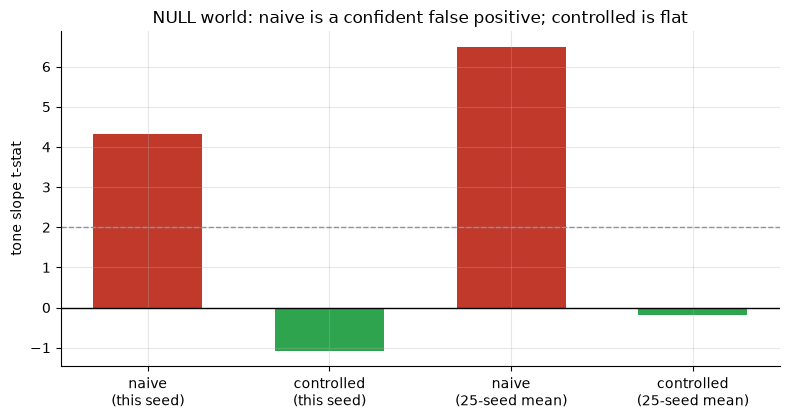

null: naive t +4.32 (mean +6.50) | controlled t -1.08 (mean -0.19)


In [3]:
pnull, _ = data.synthetic_panel(tone_beta=0.0, seed=566)
nn = st.tone_regression(pnull, control_surprise=False)['tone_t']
cc = st.tone_regression(pnull, control_surprise=True)['tone_t']
# average over 25 seeds so it's not one lucky draw
nn_bar = st.synthetic_mean_t(data, 0.0, n_seeds=25, control_surprise=False)
cc_bar = st.synthetic_mean_t(data, 0.0, n_seeds=25, control_surprise=True)
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['naive\n(this seed)','controlled\n(this seed)','naive\n(25-seed mean)','controlled\n(25-seed mean)'],
       [nn, cc, nn_bar, cc_bar], color=[RED, GREEN, RED, GREEN], width=.6)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('tone slope t-stat'); ax.set_title('NULL world: naive is a confident false positive; controlled is flat')
plt.tight_layout(); plt.show()
print(f'null: naive t {nn:+.2f} (mean {nn_bar:+.2f}) | controlled t {cc:+.2f} (mean {cc_bar:+.2f})')

> 💡 In plain words: with tone genuinely useless, the naive slope-*t* averages **+6.5** across 25 seeds — a rock-solid **false positive** — while the controlled slope-*t* averages **-0.19**, correctly flat. The surprise control is the difference between measuring tone and re-labelling PEAD.

### 4c · Robustness — H₃ (does the controlled sign hold?)

The surprise-controlled slope over four contiguous sub-panels of quarters.

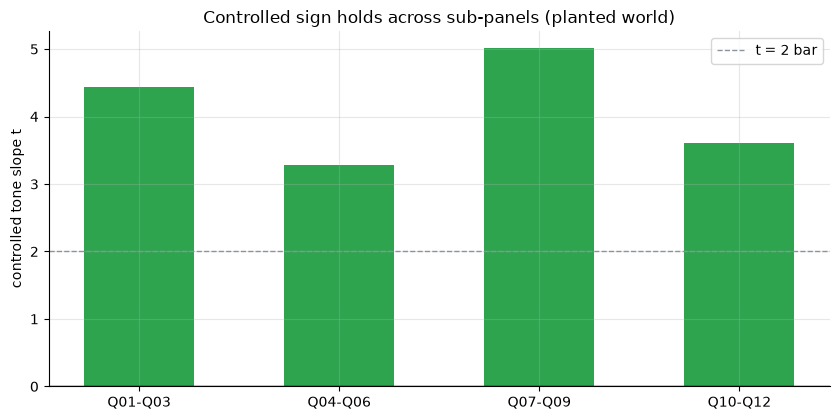

         ctrl_slope  ctrl_t
window                     
Q01-Q03       0.021   4.442
Q04-Q06       0.013   3.282
Q07-Q09       0.021   5.012
Q10-Q12       0.018   3.606


In [4]:
rows = st.robustness_windows(PANEL, n_windows=4)
tab = pd.DataFrame(rows, columns=['window','ctrl_slope','ctrl_t']).set_index('window')
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if t>0 else RED for t in tab['ctrl_t']]
ax.bar(range(len(tab)), tab['ctrl_t'], color=cols, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.index)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar'); ax.axhline(0, c='k', lw=1); ax.legend()
ax.set_ylabel('controlled tone slope t'); ax.set_title('Controlled sign holds across sub-panels (planted world)')
plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

> 💡 In plain words: H₃ holds *when the effect is truly planted* — the controlled slope is positive with *t* > 3 in all four sub-panels. On a real tape this sign-stability is exactly the open question this desk can't resolve without the data.

## 5 · The verdict

- **Signal `WEAK`** — H₂ holds on the planted panel (controlled *t* +7.95, placebo *p* 0.0005), but **no real tape** exists → `REAL` unreachable, capped `WEAK`.
- **Tradability `FRAGILE`** — naive long-short net +21.7%/yr is PEAD-inflated; the isolated edge needs vendor-grade scoring to capture, with a borrow on the guarded short.
- **Confounded by the number? `NAMED`** — naive slope-*t* +6.5 at the null is a false positive; only the controlled slope isolates the words.

## 6 · Could you trade it? — the long-short, costs and the borrow

The naive tone long-short, annualised, net of quarterly turnover and a guarded-leg borrow.

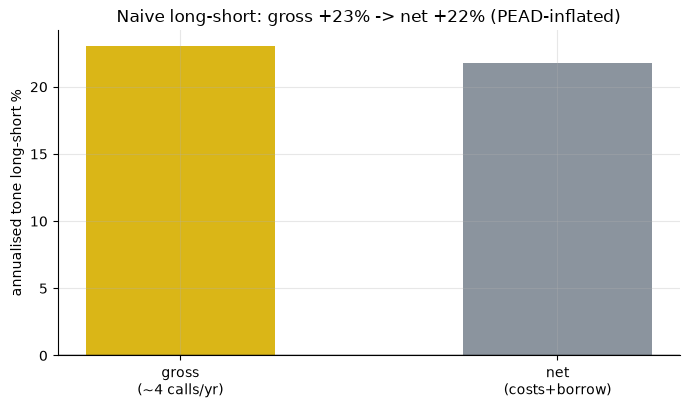

gross +23.0% -> net +21.7% (4 turns/yr x 5 bps/leg + 50 bps borrow)


In [5]:
ls = st.tone_long_short(PANEL, frac=0.3)
gross = ls['spread']*4.0*100
net = st.net_spread(ls, turns_per_year=4.0, cost_bps=5.0, borrow_ann_bps=50.0)*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross\n(~4 calls/yr)','net\n(costs+borrow)'], [gross, net], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised tone long-short %')
ax.set_title(f'Naive long-short: gross {gross:+.0f}% -> net {net:+.0f}% (PEAD-inflated)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.1f}% -> net {net:+.1f}% (4 turns/yr x 5 bps/leg + 50 bps borrow)')

> 💡 In plain words: net **+21.7%/yr** *looks* investable — but this is the **naive** book, so it's mostly earnings drift you could harvest more cheaply from the number. The pure tone residual is thin and vendor-dependent. `FRAGILE`.

## 7 · Going further — the synthetic positive control

Is the controlled engine a faithful detector, or does it always print ~0? Plant a linguistic drift of increasing strength (`tone_beta`) and watch the controlled slope-*t* climb — averaged over 25 seeds so no single lucky seed can fake it.

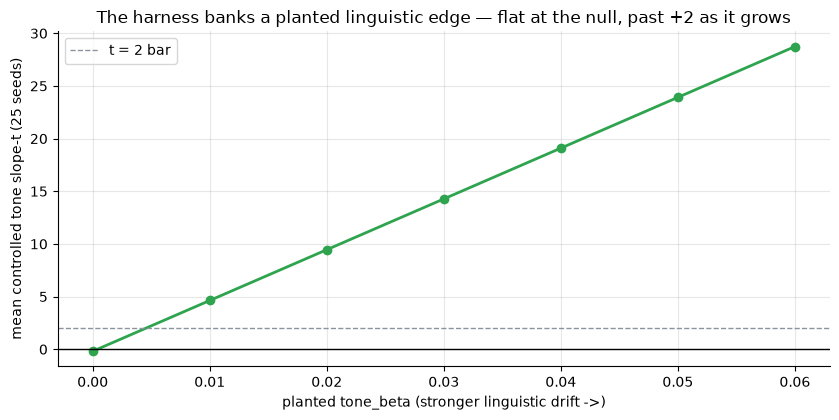

tone_beta +0.000 -> mean controlled slope-t -0.19
tone_beta +0.010 -> mean controlled slope-t +4.63
tone_beta +0.020 -> mean controlled slope-t +9.45
tone_beta +0.030 -> mean controlled slope-t +14.27
tone_beta +0.040 -> mean controlled slope-t +19.10
tone_beta +0.050 -> mean controlled slope-t +23.92
tone_beta +0.060 -> mean controlled slope-t +28.74


In [6]:
betas = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06]
ts = [st.synthetic_mean_t(data, tone_beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted tone_beta (stronger linguistic drift ->)')
ax.set_ylabel('mean controlled tone slope-t (25 seeds)')
ax.set_title('The harness banks a planted linguistic edge — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'tone_beta {b:+.3f} -> mean controlled slope-t {t:+.2f}')

The controlled slope-*t* is ≈ 0 at the null and climbs monotonically past +2 as the planted linguistic drift grows — the detector is faithful. So the honest limitation is **data availability**, not a broken engine: with no free tape of scored transcripts × event-time CAR, this desk can't lift the claim above `WEAK`. For the numeric drifts it rides on, see [363 PEAD-drift](../../363-pead-drift/) and [534 revenue-surprise-drift](../../534-revenue-surprise-drift/).